### Imports

In [43]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

SEED = 42

### Paths

In [20]:
RAW_DATA_DIR = "../data/raw"
# RAW_DATA_DIR = "../data/raw/COVID-19_Radiography_Dataset"
PADDED_DATA_DIR = "../data/padded"

CLASSES = [
    "Normal",
    "COVID",
    "Lung_Opacity",
    "Viral Pneumonia"
]

OUTPUT_DIR = "../data/processed/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

### Resize + conversion to float32

In [21]:
IMG_SIZE = 299

def load_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    return image.astype(np.float32)


def load_mask(mask_path):
    mask = cv2.imread(mask_path)
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    return (mask > 0).astype(np.float32)

def apply_lung_mask(image, mask):
    return image * mask

### Mask segmentation

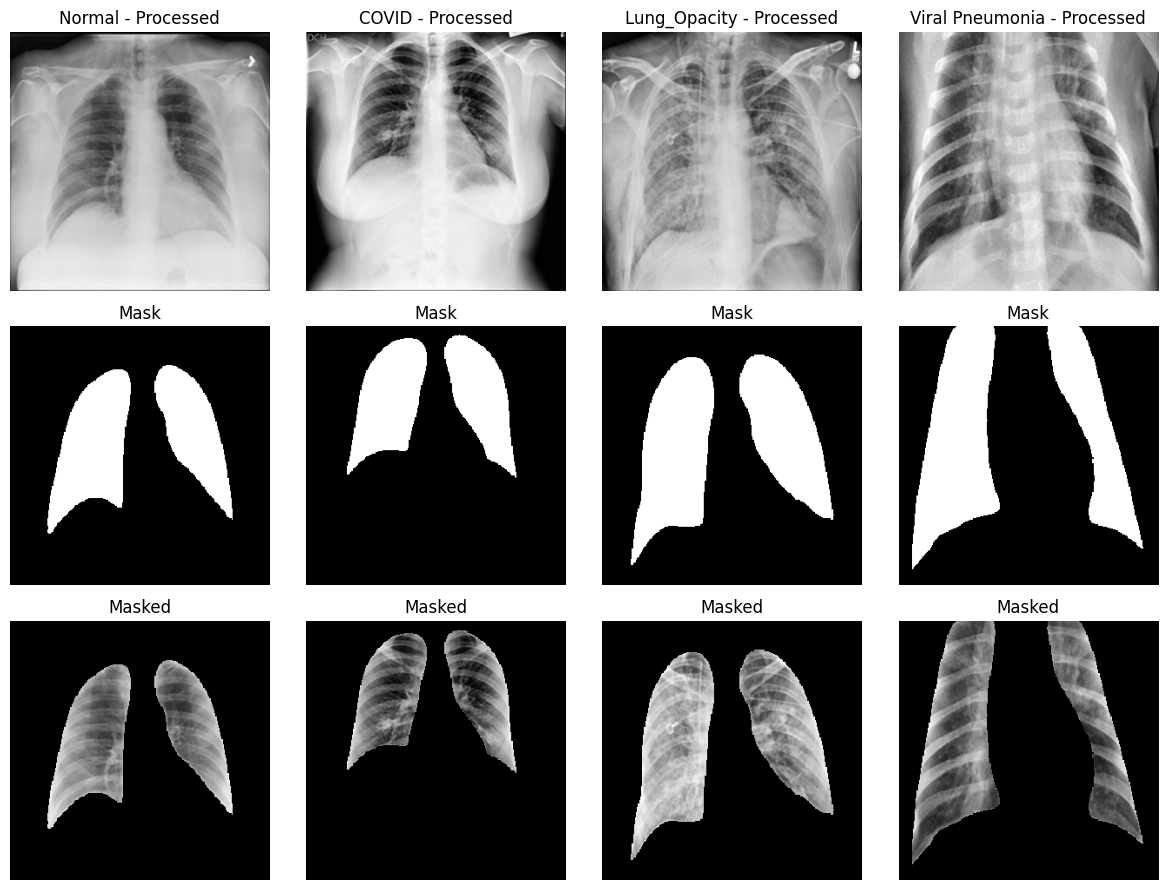

In [22]:
def show_mask_examples():
    fig, axs = plt.subplots(3, 4, figsize=(12, 9))
    for i, cls in enumerate(CLASSES):
        image_dir = os.path.join(RAW_DATA_DIR, cls, "images")
        mask_dir = os.path.join(RAW_DATA_DIR, cls, "masks")
        random.seed(SEED)
        image_name = random.choice(os.listdir(image_dir))
        image_path = os.path.join(image_dir, image_name)
        mask_path = os.path.join(mask_dir, image_name)
        image = load_image(image_path)
        image = apply_clahe(image)
        mask = load_mask(mask_path)
        masked_image = apply_lung_mask(image, mask)

        axs[0, i].imshow(image, cmap="gray")
        axs[0, i].set_title(f"{cls} - Processed")
        axs[1, i].imshow(mask, cmap="gray")
        axs[1, i].set_title("Mask")
        axs[2, i].imshow(masked_image, cmap="gray")
        axs[2, i].set_title("Masked")

    for ax in axs.flat:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_mask_examples()

### Padding removal & image cropping

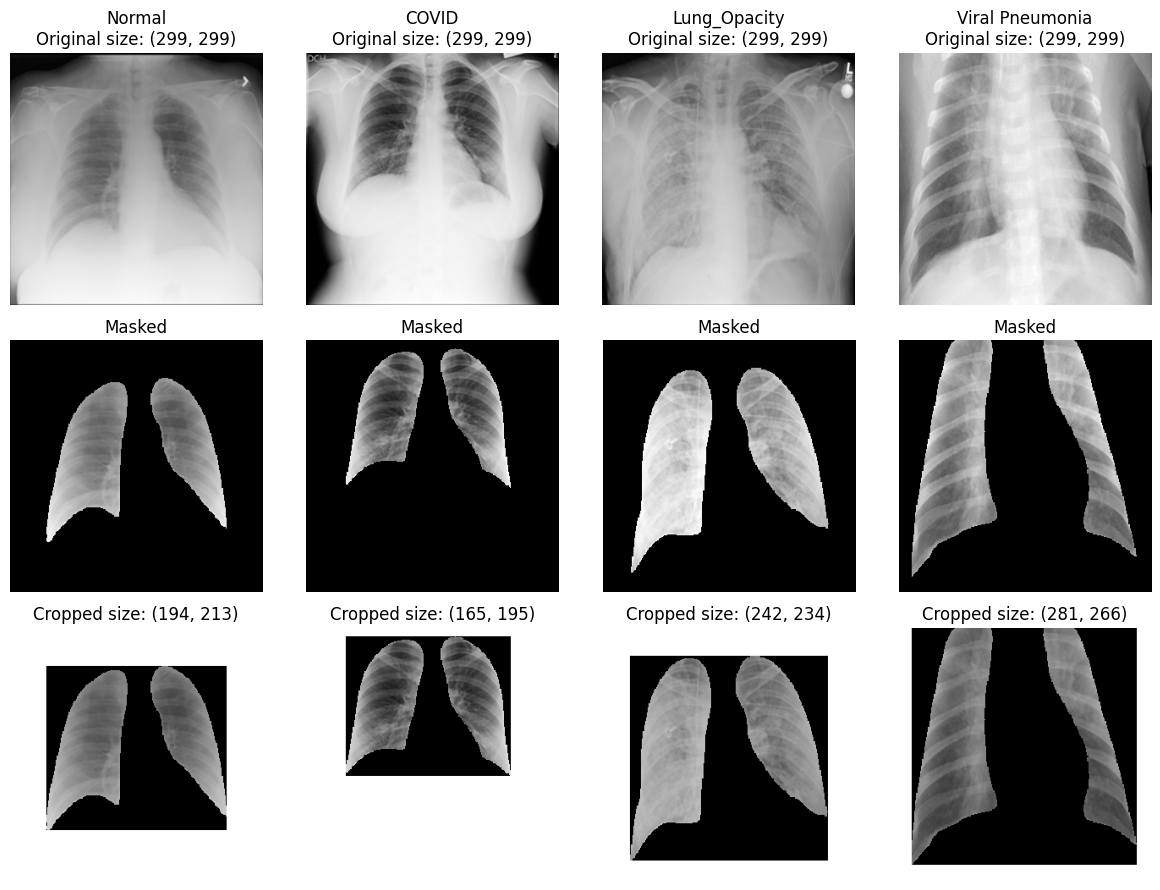

In [38]:
# def remove_padding_resize(image, mask, threshold=1):
#     original_size = image.shape[:2]
    
#     _, binary = cv2.threshold(image, threshold, 255, cv2.THRESH_BINARY)
#     coords = cv2.findNonZero(binary)
#     x, y, w, h = cv2.boundingRect(coords)
    
#     cropped_image = image[y:y+h, x:x+w]
#     cropped_mask = mask[y:y+h, x:x+w]

#     restored_image = cv2.resize(cropped_image, (original_size[1], original_size[0]))
#     restored_mask = cv2.resize(cropped_mask, (original_size[1], original_size[0]), interpolation=cv2.INTER_NEAREST)  # INTER_NEAREST pour les masques binaires

#     return restored_image, restored_mask


# def show_premoval_examples():
#     fig, axs = plt.subplots(4, 4, figsize=(12, 9))
#     for i, cls in enumerate(CLASSES):
#         image_dir = os.path.join(PADDED_DATA_DIR, cls.replace("_O", " O"))
#         os.makedirs(image_dir, exist_ok=True)
#         mask_dir = os.path.join(RAW_DATA_DIR, cls, "masks")
#         random.seed(SEED)
#         image_name = random.choice(os.listdir(image_dir))
#         image_path = os.path.join(image_dir, image_name)
#         mask_path = os.path.join(mask_dir, image_name)  

#         image = load_image(image_path)
#         mask = load_mask(mask_path)

#         restored_image, restored_mask = remove_padding_resize(image, mask)
#         final_masked = apply_lung_mask(restored_image, restored_mask)

#         axs[0, i].imshow(image, cmap="gray")
#         axs[0, i].set_title(f"{cls} - Original")
#         axs[1, i].imshow(apply_lung_mask(image, mask), cmap="grey")
#         axs[1, i].set_title(f"{cls} - Original Masked")
#         axs[2, i].imshow(restored_image, cmap="gray")
#         axs[2, i].set_title(f"{cls} - Cropped")
#         axs[3, i].imshow(final_masked, cmap="gray") 
#         axs[3, i].set_title(f"{cls} - Final Masked")

#     for ax in axs.flat:
#         ax.axis("off")

#     plt.tight_layout()
#     plt.show()

# show_premoval_examples()

def crop_black_borders(image):
    # coordonnées des pixels non noirs
    coords = np.argwhere(image > 0)

    # sécurité si image entièrement noire
    if len(coords) == 0:
        return image

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    cropped_image = image[y_min:y_max+1, x_min:x_max+1]

    return cropped_image

def crop_white_borders(image):
    # coordonnées des pixels non noirs
    coords = np.argwhere(image > 0)

    # sécurité si image entièrement noire
    if len(coords) == 0:
        return image

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    cropped_image = np.ones((299, 299), dtype=np.uint8) * 255
    cropped_image[y_min:y_max+1, x_min:x_max+1] = image[y_min:y_max+1, x_min:x_max+1]

    return cropped_image

def show_crop_examples():
    fig, axs = plt.subplots(3, 4, figsize=(12, 9))
    for i, cls in enumerate(CLASSES):
        image_dir = os.path.join(RAW_DATA_DIR, cls, "images")
        mask_dir = os.path.join(RAW_DATA_DIR, cls, "masks")
        random.seed(SEED)
        image_name = random.choice(os.listdir(image_dir))
        image_path = os.path.join(image_dir, image_name)
        mask_path = os.path.join(mask_dir, image_name)
        image = load_image(image_path)
        mask = load_mask(mask_path)
        masked_image = apply_lung_mask(image, mask)
        cropped_image = crop_black_borders(masked_image)
        cropped_image_white = crop_white_borders(masked_image)

        axs[0, i].imshow(image, cmap="gray")
        axs[0, i].set_title(f"{cls}\nOriginal size: {image.shape}")
        axs[1, i].imshow(masked_image, cmap="gray")
        axs[1, i].set_title("Masked")
        axs[2, i].imshow(cropped_image_white, cmap="gray")
        axs[2, i].set_title(f"Cropped size: {cropped_image.shape}")

    for ax in axs.flat:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    
show_crop_examples()


### Padding & resize

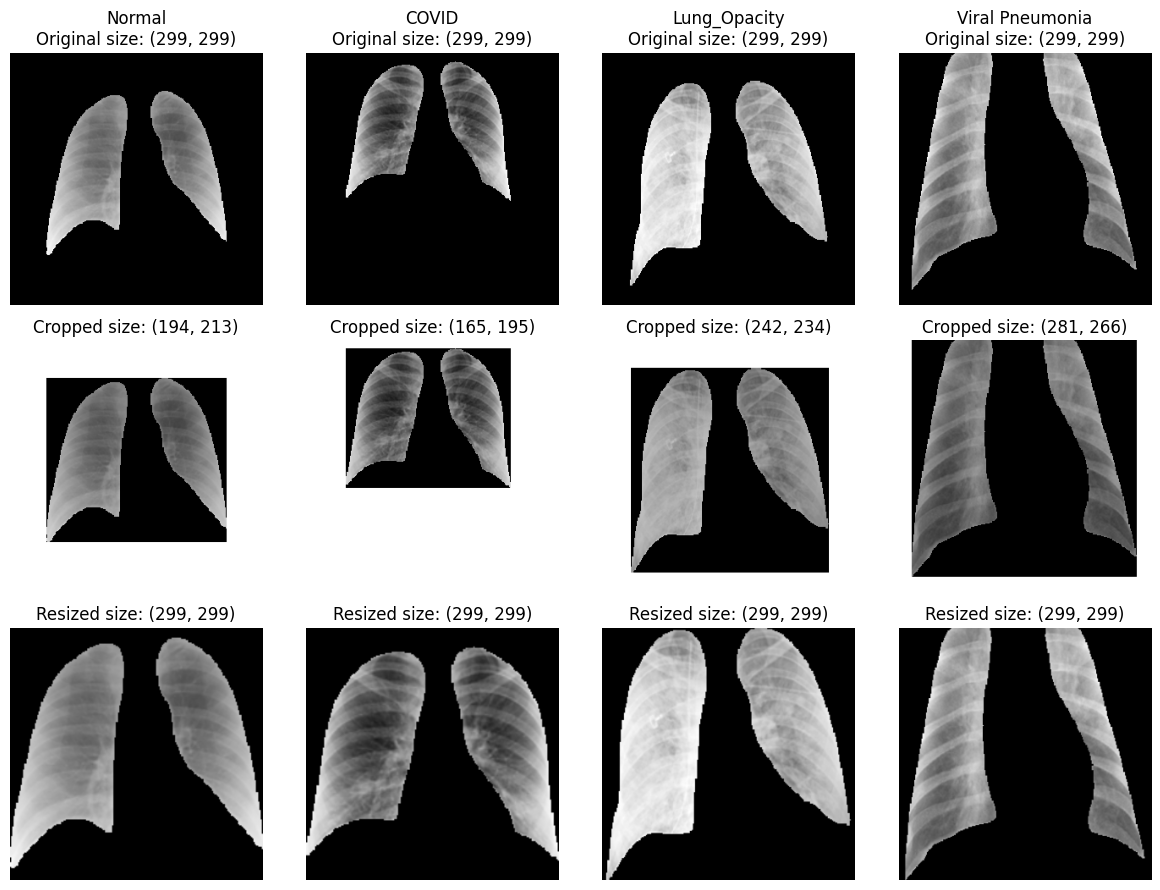

In [39]:
def add_padding(image, pad_value=0):
    h, w = image.shape[:2]
    if h == w:
        return image
    size = max(h, w)
    pad_top = (size - h) // 2
    pad_bottom = size - h - pad_top
    pad_left = (size - w) // 2
    pad_right = size - w - pad_left

    padded_image = cv2.copyMakeBorder(
        image,
        pad_top,
        pad_bottom,
        pad_left,
        pad_right,
        borderType=cv2.BORDER_CONSTANT,
        value=pad_value
    )

    return padded_image

def resize_image(image, size=299):

    return cv2.resize(image, (size, size), interpolation=cv2.INTER_LINEAR)
    
    
def show_pad_resize_examples():
    fig, axs = plt.subplots(3, 4, figsize=(12, 9))
    for i, cls in enumerate(CLASSES):
        image_dir = os.path.join(RAW_DATA_DIR, cls, "images")
        mask_dir = os.path.join(RAW_DATA_DIR, cls, "masks")
        random.seed(SEED)
        image_name = random.choice(os.listdir(image_dir))
        image_path = os.path.join(image_dir, image_name)
        mask_path = os.path.join(mask_dir, image_name)
        image = load_image(image_path)
        mask = load_mask(mask_path)
        masked_image = apply_lung_mask(image, mask)
        cropped_image = crop_black_borders(masked_image)
        cropped_image_white = crop_white_borders(masked_image)
        padded_image = add_padding(cropped_image)
        resized_image = resize_image(padded_image)

        axs[0, i].imshow(masked_image, cmap="gray")
        axs[0, i].set_title(f"{cls}\nOriginal size: {masked_image.shape}")
        axs[1, i].imshow(cropped_image_white, cmap="gray")
        axs[1, i].set_title(f"Cropped size: {cropped_image.shape}")
        axs[2, i].imshow(resized_image, cmap="gray")
        axs[2, i].set_title(f"Resized size: {resized_image.shape}")

    for ax in axs.flat:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    
show_pad_resize_examples()


### CLAHE (contrast increase)

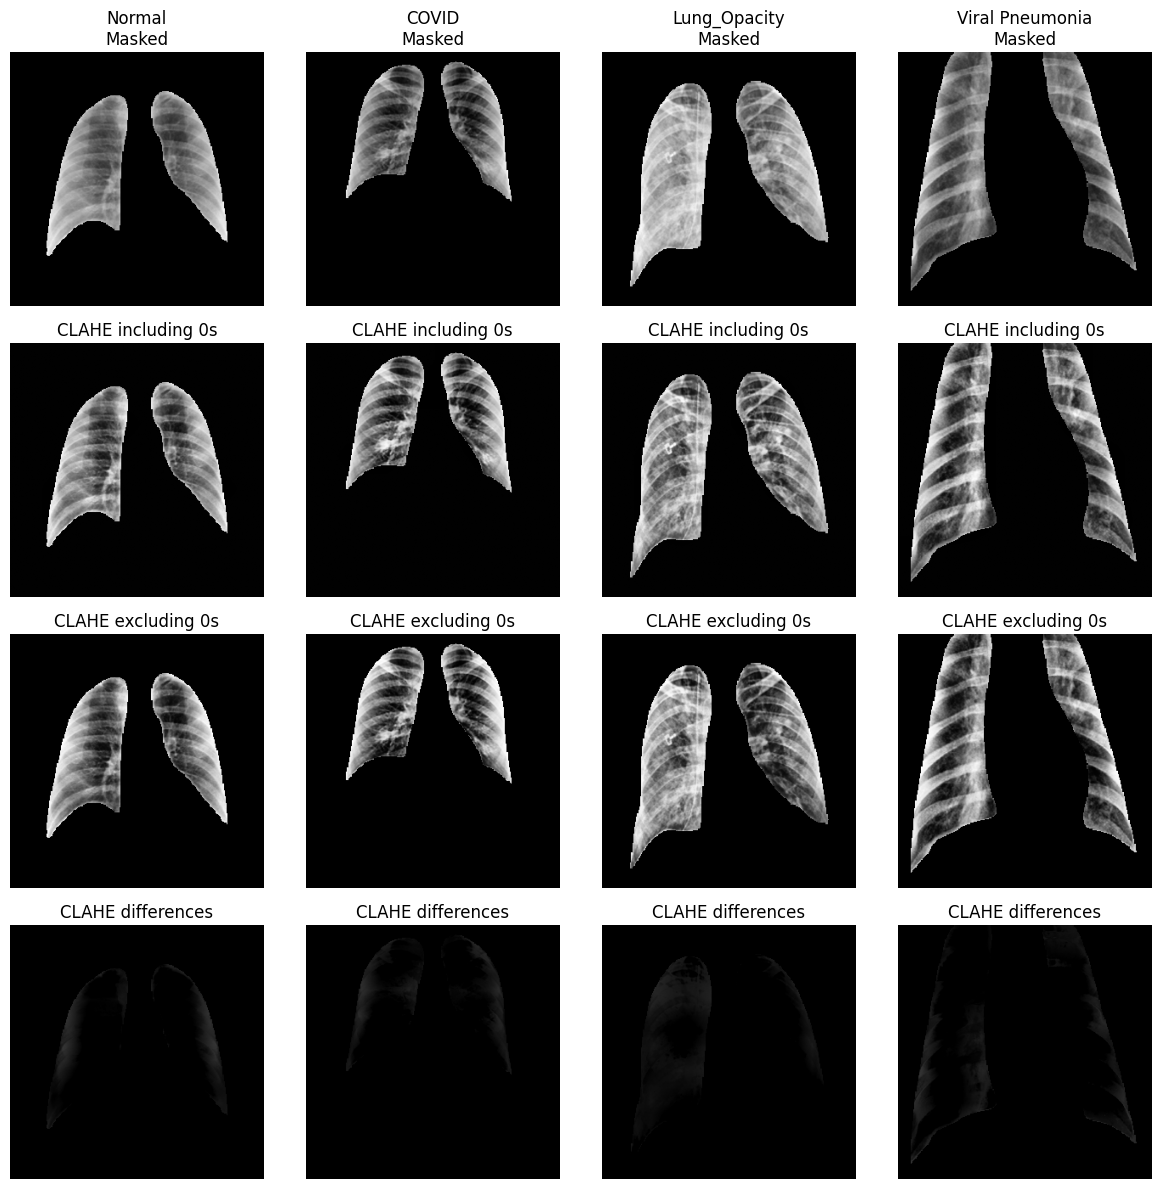

In [25]:
def apply_clahe(image):
    image_uint8 = image.astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(image_uint8).astype(np.float32)

def apply_clahe_nonzero(image):
    image_uint8 = image.astype(np.uint8)
    mask = image_uint8 > 0
    result = np.zeros_like(image_uint8)
    if np.any(mask):
        pixels = image_uint8[mask]
        # CLAHE nécessite une image 2D
        pixels_img = pixels.reshape(-1, 1)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        
        pixels_clahe = clahe.apply(pixels_img).flatten()
        result[mask] = pixels_clahe
    return result.astype(np.float32)


def show_clahe_examples():
    fig, axs = plt.subplots(4, 4, figsize=(12, 12))
    for i, cls in enumerate(CLASSES):
        image_dir = os.path.join(RAW_DATA_DIR, cls, "images")
        mask_dir = os.path.join(RAW_DATA_DIR, cls, "masks")
        random.seed(SEED)
        image_name = random.choice(os.listdir(image_dir))
        image_path = os.path.join(image_dir, image_name)
        mask_path = os.path.join(mask_dir, image_name)
        image = load_image(image_path)
        image = apply_clahe(image)
        mask = load_mask(mask_path)
        masked_image = apply_lung_mask(image, mask)
        clahe_image = apply_clahe(masked_image)
        clahe_non_zero_image = apply_clahe_nonzero(masked_image)

        axs[0, i].imshow(masked_image, cmap="gray")
        axs[0, i].set_title(f"{cls}\nMasked")
        axs[1, i].imshow(clahe_image, cmap="gray")
        axs[1, i].set_title("CLAHE including 0s")
        axs[2, i].imshow(clahe_non_zero_image, cmap="gray")
        axs[2, i].set_title("CLAHE excluding 0s")
        axs[3, i].imshow(clahe_non_zero_image - clahe_image, cmap="gray", vmin=0, vmax=255)
        axs[3, i].set_title("CLAHE differences")

    for ax in axs.flat:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_clahe_examples()

### Normalization (inutile offline mais à faire lors de l'entrainement)

In [10]:
# def normalize_image(image):
#     image = image.astype(np.float32)
#     image = image / 255.0
#     return image

### Save pre-processed data

In [36]:
for cls in CLASSES:

    image_dir = os.path.join(RAW_DATA_DIR, cls, "images")
    mask_dir = os.path.join(RAW_DATA_DIR, cls, "masks")

    output_class_dir_clahe = os.path.join(OUTPUT_DIR, "clahe", cls)
    output_class_dir_no_clahe = os.path.join(OUTPUT_DIR, "no_clahe", cls)
    os.makedirs(output_class_dir_clahe, exist_ok=True)
    os.makedirs(output_class_dir_no_clahe, exist_ok=True)
    image_names = os.listdir(image_dir)
    for image_name in tqdm(image_names, desc=cls):
        image_path = os.path.join(image_dir, image_name)
        mask_path = os.path.join(mask_dir, image_name)
        # LOAD
        image = load_image(image_path)
        mask = load_mask(mask_path)
        # MASK
        image = apply_lung_mask(image, mask)
        # CROPPING
        image = crop_black_borders(image)
        # PADDING
        image = add_padding(image)
        # RESIZING
        image = resize_image(image, size=299)
        # SAVE before CLAHE
        output_path = os.path.join(output_class_dir_no_clahe, image_name)
        image_to_save = (image).astype(np.uint8)
        cv2.imwrite(output_path, image_to_save)
        # CLAHE
        image = apply_clahe(image)
        # SAVE after CLAHE
        output_path = os.path.join(output_class_dir_clahe, image_name)
        image_to_save = (image).astype(np.uint8)
        cv2.imwrite(output_path, image_to_save)

print("Preprocessing completed.")

Normal:   0%|          | 0/10192 [00:00<?, ?it/s]

Viral Pneumonia: 100%|██████████| 1345/1345 [00:22<00:00, 59.49it/s]

Preprocessing completed.


### Visualise pre-processed data

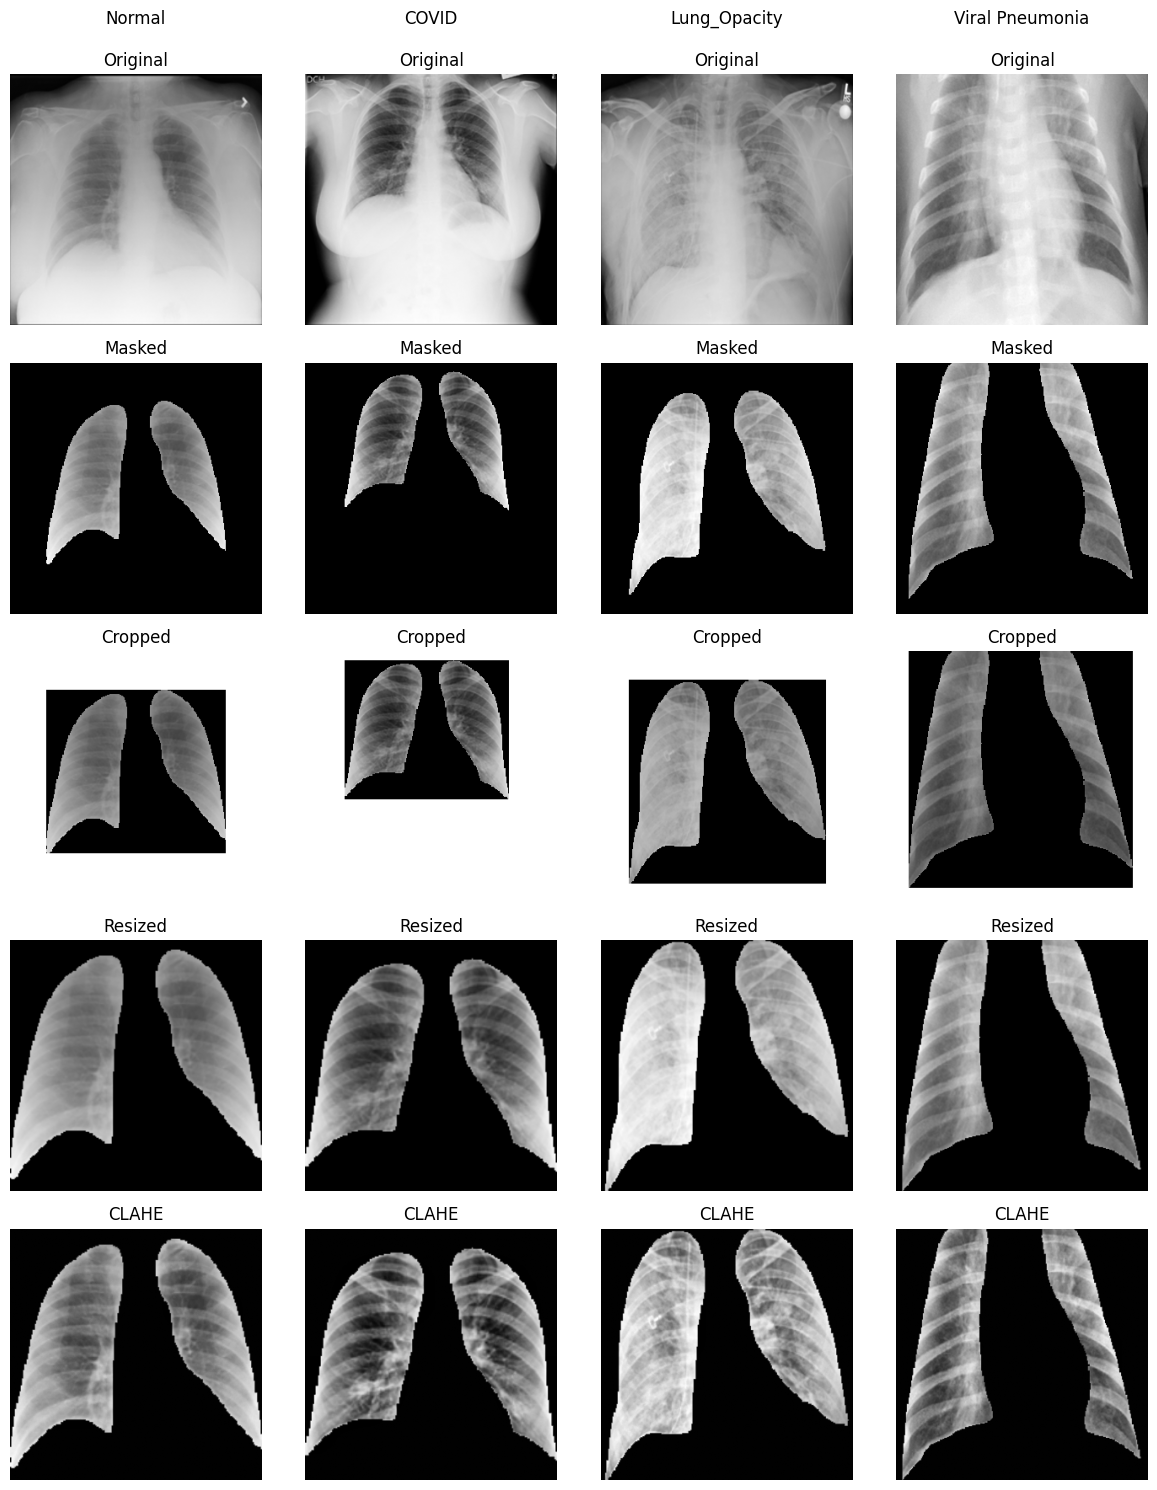

In [51]:
def show_preprocessed_examples():
    fig, axs = plt.subplots(5, 4, figsize=(12, 15))
    for i, cls in enumerate(CLASSES):
        image_dir = os.path.join(RAW_DATA_DIR, cls, "images")
        mask_dir = os.path.join(RAW_DATA_DIR, cls, "masks")
        random.seed(SEED)
        image_name = random.choice(os.listdir(image_dir))
        image_path = os.path.join(image_dir, image_name)
        mask_path = os.path.join(mask_dir, image_name)
        # LOAD
        image = load_image(image_path)
        mask = load_mask(mask_path)
        # MASK
        masked_image = apply_lung_mask(image, mask)
        # CROPPING
        cropped_image = crop_black_borders(masked_image)
        cropped_image_white = crop_white_borders(masked_image)
        # PADDING
        padded_image = add_padding(cropped_image)
        # RESIZING
        resized_image = resize_image(padded_image, size=299)
        # CLAHE
        clahe_image = apply_clahe(resized_image)
        

        axs[0, i].imshow(image, cmap="gray")
        axs[0, i].set_title(f"{cls}\n\nOriginal")
        axs[1, i].imshow(masked_image, cmap="gray")
        axs[1, i].set_title("Masked")
        axs[2, i].imshow(cropped_image_white, cmap="gray")
        axs[2, i].set_title("Cropped")
        axs[3, i].imshow(resized_image, cmap="gray")
        axs[3, i].set_title("Resized")
        axs[4, i].imshow(clahe_image, cmap="gray")
        axs[4, i].set_title("CLAHE")

    for ax in axs.flat:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_preprocessed_examples()